In [1]:
from sklearn.datasets import make_moons

# Generating the Moon Dataset

In this step, we generate a synthetic dataset using Scikit-learn's **`make_moons()`** function. The Moon dataset consists of two interleaving crescent-shaped classes, making it a popular benchmark for testing machine learning algorithms on **non-linear classification problems**.

Unlike linearly separable datasets, the Moon dataset requires models to learn curved decision boundaries, making it ideal for understanding the strengths and limitations of different classification algorithms.

### Parameters Used

- **`n_samples=300`**: Generates a total of 300 data points.
- **`noise=0.05`**: Adds a small amount of random noise to make the dataset more realistic and challenging.
- **`random_state=42`**: Ensures the dataset is generated the same way every time the notebook is executed, improving reproducibility.

The function returns:
- **`X`**: A matrix containing the feature values (coordinates of each sample).
- **`y`**: The corresponding class labels (0 or 1) for each sample.

In [2]:
X, y = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42
)

## Data Standardization

Machine learning models often perform better when features are on a similar scale. We use **StandardScaler** to transform the data so that each feature has a mean of **0** and a standard deviation of **1**.

Standardization improves training stability and is especially important for distance-based algorithms. After scaling, we visualize the standardized data using a scatter plot to observe its distribution.

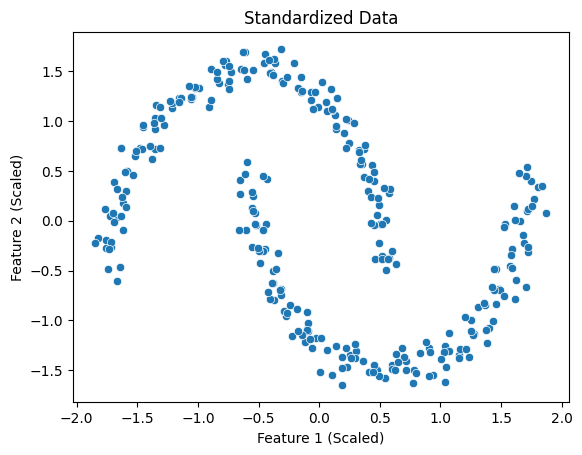

In [3]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Create scaler object
scaler = StandardScaler()

# Scale the data
X_scaled = scaler.fit_transform(X)

# Scatter plot
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1])

plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.title("Standardized Data")
plt.show()

## Applying DBSCAN Clustering

In this step, we apply the **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** algorithm to the standardized data. DBSCAN groups closely packed data points into clusters while identifying isolated points as **noise or outliers**.

Here, `eps=0.5` defines the neighborhood radius, and `min_samples=5` specifies the minimum number of nearby points required to form a cluster.

In [4]:
from sklearn.cluster import DBSCAN

# DBSCAN
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)


## Visualizing the Clusters

After applying DBSCAN, we visualize the clustering results using a scatter plot. Each color represents a different cluster identified by the algorithm, while points labeled as **-1** are treated as noise. This visualization helps us understand how DBSCAN groups data based on density rather than predefined cluster shapes.

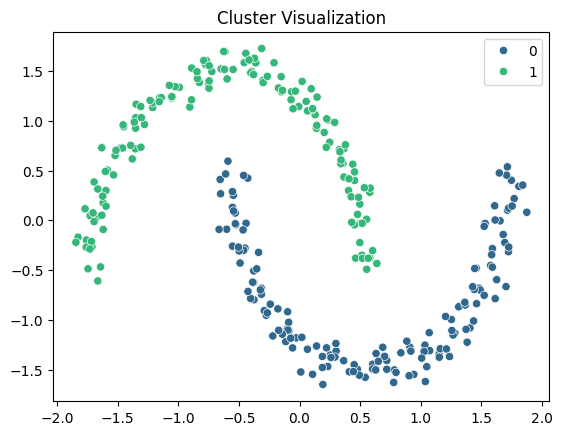

In [5]:
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette="viridis")
plt.title("Cluster Visualization")
plt.show()